In [6]:
import os 
from Bio import SeqIO
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import sklearn
import numpy as np

In [9]:
#Load data 
file_OGT ="../Data/Figure1/ogt.fasta"
file_Meltome="../Data/Figure1/meltome_atlas.fasta"
file_Meltome_annot = "../Data/Figure1/meltome_atlas_annot.fasta"


df = {"id":[], "Temperature":[],"Seq":[],"Dataset":[]}
count_OGT = 0
count_IMG = 0
count_meltome = 0
for i, rec in enumerate(SeqIO.parse(file_OGT,"fasta")):
    df["id"].append(rec.id)
    df["Temperature"].append(float(rec.description.split()[-1]))
    df["Seq"].append(str(rec.seq))
    #if rec.description.split()[-2] == "OGT":
    df["Dataset"].append("OGT")
    count_OGT += 1 
    #else: 
    #    df["Dataset"].append("IMG")
    #    count_IMG += 1 

for i, rec in enumerate(SeqIO.parse(file_Meltome,"fasta")):
    df["id"].append(rec.id)
    df["Temperature"].append(float(rec.description.split()[-1]))
    df["Seq"].append(str(rec.seq))
    df["Dataset"].append("Meltome")
    count_meltome += 1
    
for i, rec in enumerate(SeqIO.parse(file_Meltome_annot,"fasta")):
    df["id"].append(rec.id)
    df["Temperature"].append(float(rec.description.split()[-2]))
    df["Seq"].append(str(rec.seq))
    df["Dataset"].append("Meltome_annot")
    count_meltome += 1
    
df = pd.DataFrame(df)

df.loc[np.logical_and(df["Dataset"] == "IMG",df["Temperature"]>40)].shape[0]

df_TM = df.loc[df["Dataset"] == "Meltome"]
df_TM_annot = df.loc[df["Dataset"] == "Meltome_annot"]
df_OGT = df.loc[df["Dataset"] == "OGT"]

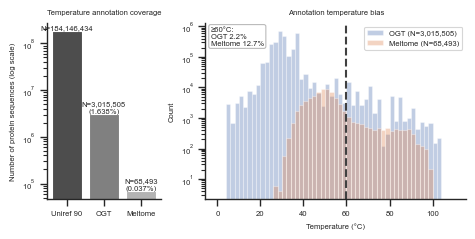

In [ ]:


sns.set_theme(style="ticks", context="paper")

N_uniprot = 184146434 # 20/1 - 26
N_ogt = sum(df["Dataset"] == "OGT")
N_meltome = sum(df["Dataset"] == "Meltome")

ogt_temps = np.asarray(df.loc[df["Dataset"] == "OGT"]["Temperature"])
meltome_temps = np.asarray(df.loc[df["Dataset"] == "Meltome"]["Temperature"])

cut = 60  # or your chosen thermophile threshold


# --- style ---
plt.rcParams.update({
    "font.size": 5.5,
    "axes.labelsize": 5.5,
    "axes.titlesize": 5.5,
    "axes.linewidth": 1,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 5.5,
    "legend.fontsize": 5.5,
})

mm = 1 / 25.4
fig_w = 120 * mm
fig_h = 60 * mm





fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(fig_w, fig_h),
    gridspec_kw={"width_ratios": [0.7, 1.6]}
)

# --- Panel A: Coverage (log bar) ---
labels = ["Uniref 90", "OGT", "Meltome"]
counts = [N_uniprot, N_ogt, N_meltome]

ax1.bar(labels, counts, color=["0.3", "0.5", "0.7"])
ax1.set_yscale("log")
ax1.set_ylabel("Number of protein sequences (log scale)")
ax1.set_title("Temperature annotation coverage")

# annotate N and percent of UniProt for annotated sets
for i, (lab, c) in enumerate(zip(labels, counts)):
    if lab == "Uniref 90":
        txt = f"N={c:,}"
    else:
        txt = f"N={c:,}\n({100*c/N_uniprot:.3f}%)"
    ax1.text(i, c, txt, ha="center", va="bottom", fontsize=5.5)

sns.despine(ax=ax1)

# --- Panel B: Temperature distribution (counts) ---
bins = np.arange(0, 111, 2)  # choose bin width you like

ax2.hist(ogt_temps, bins=bins, alpha=0.35, label=f"OGT (N={len(ogt_temps):,})")
ax2.hist(meltome_temps, bins=bins, alpha=0.35, label=f"Meltome (N={len(meltome_temps):,})")

ax2.axvline(cut, ls="--", lw=1.5, color="0.25")
ax2.set_yscale("log")
ax2.set_xlabel("Temperature (°C)")
ax2.set_ylabel("Count")
ax2.set_title("Annotation temperature bias")

# tail annotations
ogt_hot = np.mean(ogt_temps >= cut)
mel_hot = np.mean(meltome_temps >= cut)
ax2.text(0.02, 0.98,
         f"≥{cut}°C:\nOGT {ogt_hot*100:.1f}%\nMeltome {mel_hot*100:.1f}%",
         transform=ax2.transAxes, va="top", ha="left",
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9))

ax2.legend(frameon=True)
sns.despine(ax=ax2)

fig.tight_layout()

plt.savefig("../Results/Figure2/coverage_and_bias.pdf", bbox_inches="tight")

R square 0.7695843778979886  
MSE 154.77282109556333
Median absolute error 6.688182830810547
Explained varience 0.7772774130778318
Pearson correlation 0.8818996283488887
Spearman correlation 0.8686830038193181


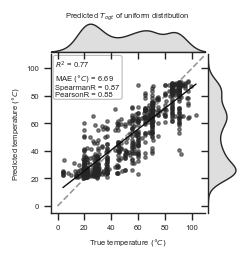

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style="ticks", context="paper")

#Load regression prediction data 

df = pd.read_csv("../Data/Figure1/Evaluation_regression_downsampled_test_set.csv")

# Statistics

r = sklearn.metrics.r2_score(df["True OGT"], df["Predicted OGT"])
e = sklearn.metrics.explained_variance_score(df["True OGT"], df["Predicted OGT"])
mse = sklearn.metrics.mean_squared_error(df["True OGT"], df["Predicted OGT"])
mdi = sklearn.metrics.median_absolute_error(df["True OGT"], df["Predicted OGT"])

corr_p, _ = pearsonr(df["True OGT"], df["Predicted OGT"])
corr_s, _ = spearmanr(df["True OGT"], df["Predicted OGT"])
print("R square {}  ".format(r))
print("MSE {}".format(mse))
print("Median absolute error {}".format(mdi))
print("Explained varience {}".format(e))
print("Pearson correlation {}".format(corr_p))
print("Spearman correlation {}".format(corr_s))


SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# --- style ---
plt.rcParams.update({
    "font.size": 5.5,
    "axes.labelsize": 5.5,
    "axes.titlesize": 5.5,
    "figure.titlesize": 5.5,
    "axes.linewidth": 1,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 5.5,
    "legend.fontsize": 5.5,
})
mm = 1 / 25.4
fig_w = 60 * mm
fig_h = 60 * mm


#fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# JointGrid with marginal KDEs
g = sns.JointGrid(
    data=df, x="True OGT", y="Predicted OGT",
    height=fig_h, ratio=5, space=0.08, marginal_ticks=False
)

# --- Main panel: scatter + regression line (or omit regression if you prefer) ---
sns.regplot(
    data=df, x="True OGT", y="Predicted OGT",
    ci=None,
    scatter_kws={"s": 6, "alpha": 0.55, "color": "0.15"},
    line_kws={"color": "0.05", "lw": 1},
    ax=g.ax_joint
)

# Identity line y=x
g.ax_joint.plot([0, 110], [0, 110], ls="--", lw=1.2, color="0.6", zorder=0)

# --- Marginals: KDEs on axes ---
sns.kdeplot(
    data=df, x="True OGT",
    ax=g.ax_marg_x, color="0.15", lw=1, fill=True, alpha=0.15, clip=(-5, 110)
)
sns.kdeplot(
    data=df, y="Predicted OGT",
    ax=g.ax_marg_y, color="0.15", lw=1, fill=True, alpha=0.15, clip=(-5, 110)
)

# Limits + labels + title
g.ax_joint.set_xlim(-5, 110)
g.ax_joint.set_ylim(-5, 110)

g.ax_joint.set_xlabel(r"True temperature $(\degree C)$")
g.ax_joint.set_ylabel(r"Predicted temperature $(\degree C)$")
#g.ax_joint.set_title(r"Predicted $T_{ogt}$ of uniform distribution", pad=12)
g.fig.suptitle(r"Predicted $T_{ogt}$ of uniform distribution", y=1.02)
# Optional: statistics text box in joint axis
textstr = "\n".join([
    fr"$R^2$ = {r:.2f}",
    fr"MAE $(\degree C)$ = {mdi:.2f}",
    fr"SpearmanR = {corr_s:.2f}",
    fr"PearsonR = {corr_p:.2f}",
])
g.ax_joint.text(
    0.03, 0.97, textstr, transform=g.ax_joint.transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9)
)

sns.despine(ax=g.ax_joint)
sns.despine(ax=g.ax_marg_x, left=True)
sns.despine(ax=g.ax_marg_y, bottom=True)

plt.savefig("../Results/Figure1/img_reg_marginal_kde.pdf", bbox_inches="tight")
plt.show()

# Plotting COGs containing Thermophiles

Annotations data from 

* Meltome atlas
* OGT data
* Swiss Prot
* Uniprot    

Meltome and OGT have their experimental values used to determain Thermophilicity while Swiss and Uni Prot use their predicted values. 

In [ ]:
# Load annotation files

# Meltome Atlas
file_annotation_MeltomeAtlas="../Data/Figure1/meltome_atlas_annot.emapper.annotations"
df_meltome = pd.read_csv(file_annotation_MeltomeAtlas, sep = '\t', header=4)

# OGT data
file_annotation_ogt="../Data/Figure1/OGT.emapper.annotations"
df_ogt = pd.read_csv(file_annotation_ogt, sep = '\t', header=4)

# Swiss data
file_annotation_swiss="../Data/Figure1/SwissProt.emapper.annotations"
df_swiss = pd.read_csv(file_annotation_swiss, sep = '\t', header=4)

# Uniprot data
file_annotation_uniprot="../Data/Figure1/Uniprot.emapper.annotations"
df_uniprot = pd.read_csv(file_annotation_uniprot, sep = '\t', header=4)